# Post Image Processing — Despeckling Results

Synthetic B-mode testbench (`gen_us.py`) + quality metrics (`metrics.py`). Run this notebook top to bottom to see all outputs inline.

In [ ]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

IMG_DIR = "img"
%matplotlib inline

## Raw B-mode vs. Ground Truth

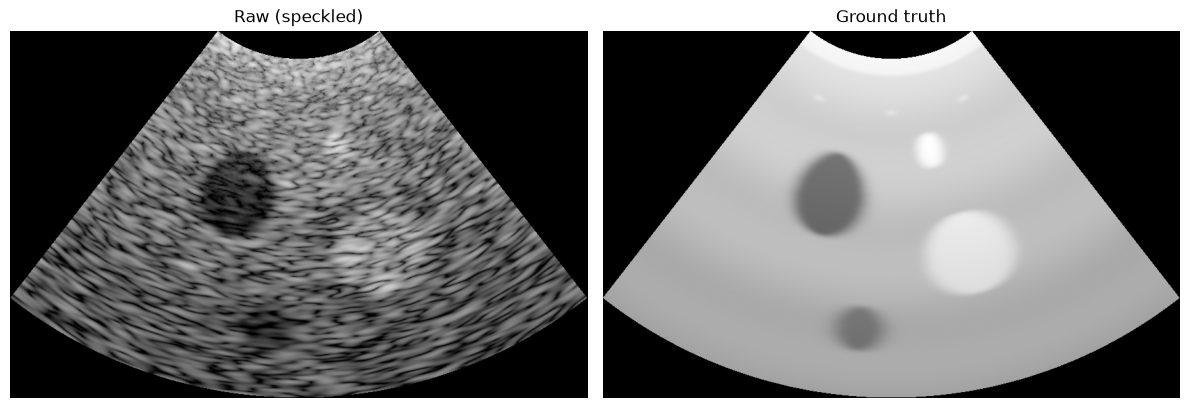

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
for ax, name, title in zip(axes, ["us_raw", "us_gt"], ["Raw (speckled)", "Ground truth"]):
    ax.imshow(mpimg.imread(f"{IMG_DIR}/{name}.png"), cmap="gray")
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
plt.show()

## Despeckling Filter Outputs

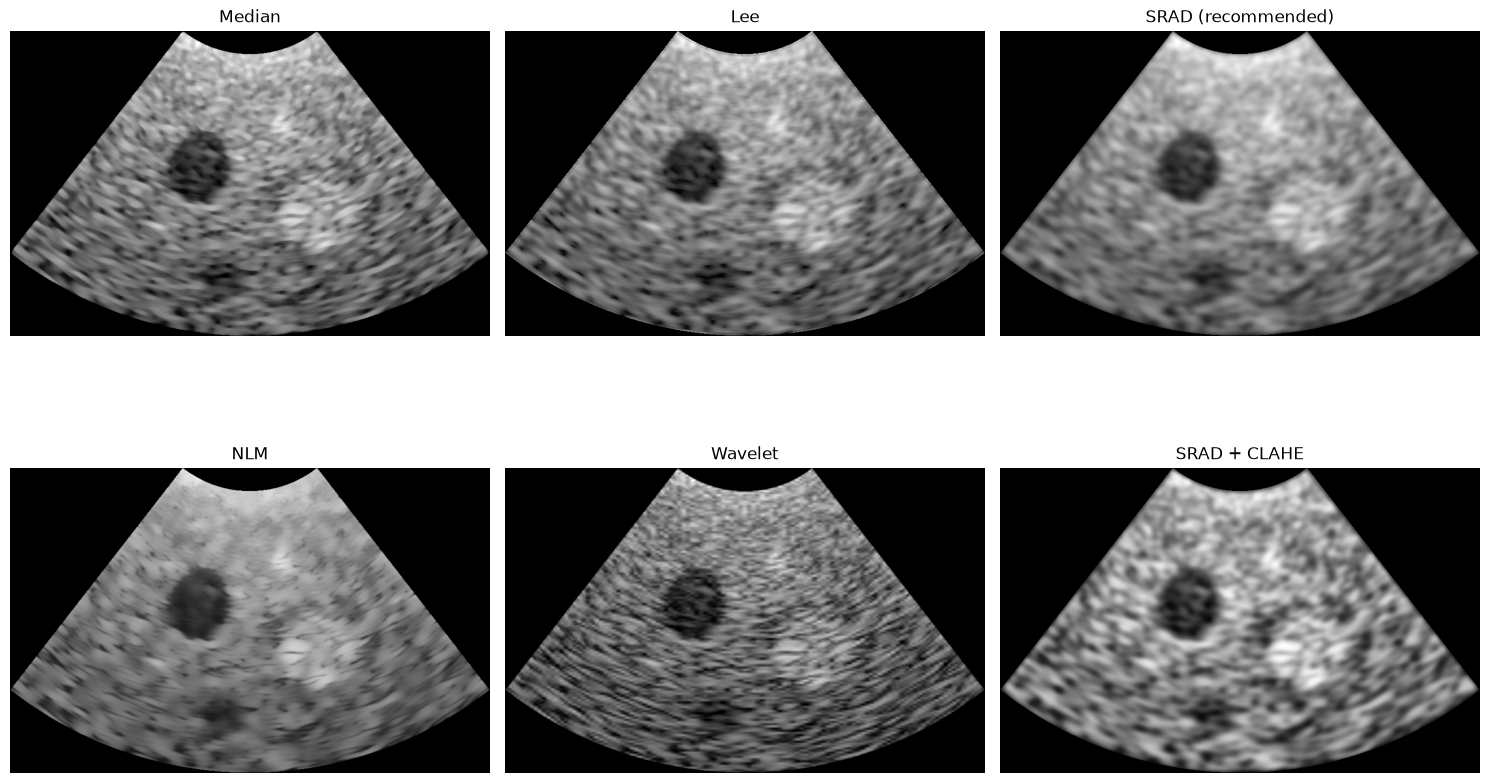

In [ ]:
filters = [
    ("f_median", "Median"),
    ("f_lee", "Lee"),
    ("f_srad", "SRAD (recommended)"),
    ("f_nlm", "NLM"),
    ("f_wavelet", "Wavelet"),
    ("f_enhanced", "SRAD + CLAHE"),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for ax, (fname, title) in zip(axes.flat, filters):
    ax.imshow(mpimg.imread(f"{IMG_DIR}/{fname}.png"), cmap="gray")
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
plt.show()

## Quality Metrics

In [ ]:
with open("metrics.json") as f:
    metrics = json.load(f)

df = pd.DataFrame(metrics).T
df = df[["CNR", "SNR", "PSNR", "SSIM", "EPI"]].round(3)
df

,CNR,SNR,PSNR,SSIM,EPI
Original (raw),1.778,4.282,11.050,0.484,1.000
Median,2.454,7.075,11.578,0.625,0.759
Lee,2.575,7.553,11.239,0.667,0.943
SRAD,2.980,9.292,11.239,0.744,0.955
NLM,3.035,9.770,11.408,0.728,0.806
Wavelet,2.002,5.079,11.030,0.509,0.570
SRAD + CLAHE,2.266,5.023,12.228,0.640,0.827


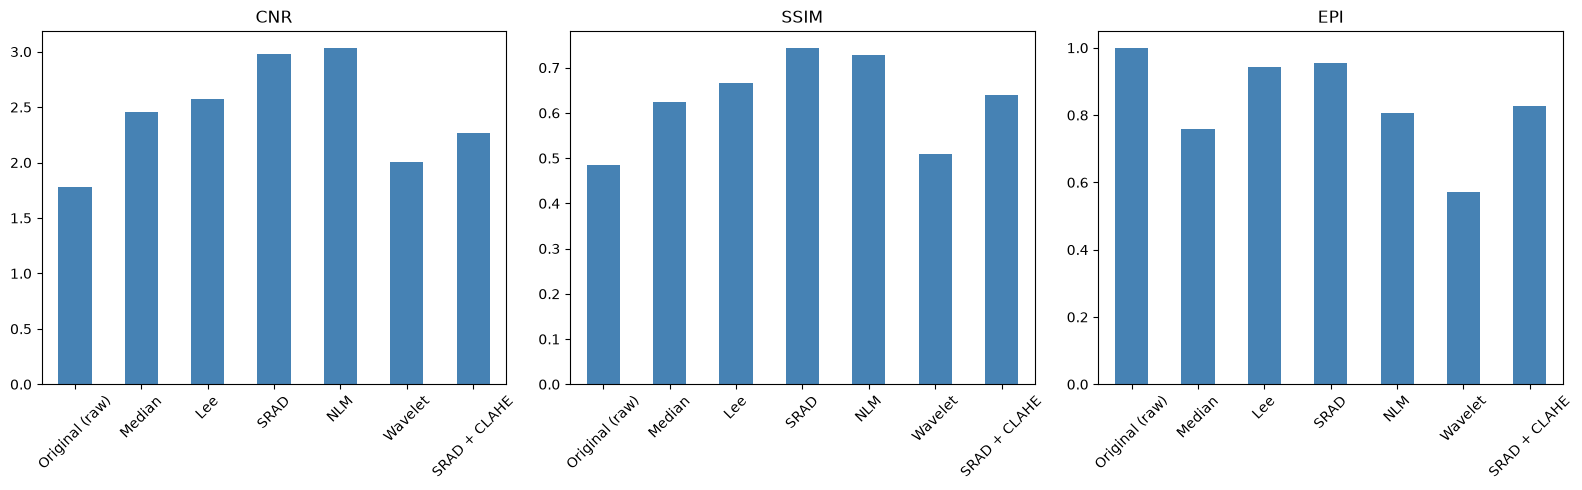

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, metric in zip(axes, ["CNR", "SSIM", "EPI"]):
    df[metric].plot(kind="bar", ax=ax, color="steelblue")
    ax.set_title(metric)
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()